In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [3]:
df=pd.read_csv('titanic_toy.csv')

In [4]:
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       714 non-null    float64
 1   Fare      846 non-null    float64
 2   Family    891 non-null    int64  
 3   Survived  891 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 28.0 KB


In [8]:
df.isnull().sum()

Age         177
Fare         45
Family        0
Survived      0
dtype: int64

In [9]:
df.isnull().mean()

Age         0.198653
Fare        0.050505
Family      0.000000
Survived    0.000000
dtype: float64

In [10]:
x=df.drop(columns=['Survived'])
y=df['Survived']

In [12]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [13]:
X_train.shape,X_test.shape

((712, 3), (179, 3))

In [14]:
X_train.isnull().mean()

Age       0.207865
Fare      0.050562
Family    0.000000
dtype: float64

In [15]:
mean_age=X_train['Age'].mean()
median_age=X_train['Age'].median()

mean_fare=X_train['Fare'].mean()
median_fare=X_train['Fare'].median()

In [16]:
X_train['Age_median']=X_train['Age'].fillna(median_age)
X_train['age_mean']=X_train['Age'].fillna(mean_age)

X_train['fare_mean']=X_train['Fare'].fillna(mean_fare)
X_train['fare_median']=X_train['Fare'].fillna(median_fare)

In [18]:
X_train.sample(5)

,Age,Fare,Family,Age_median,age_mean,fare_mean,fare_median
491,21.0,7.2500,0,21.00,21.000000,7.2500,7.2500
150,51.0,12.5250,0,51.00,51.000000,12.5250,12.5250
695,52.0,13.5000,0,52.00,52.000000,13.5000,13.5000
295,NaN,27.7208,0,28.75,29.785904,27.7208,27.7208
806,39.0,0.0000,0,39.00,39.000000,0.0000,0.0000


In [20]:
print("Orignal age variable variance:",X_train['Age'].var())
print("age variance after meadian imputer:",X_train['Age_median'].var())
print("age variance after mean imputer:",X_train["age_mean"].var())

print("orignal Fare Variable variance :",X_train['Fare'].var())
print("Fare Variance after median Imputation:",X_train['fare_mean'].var())
print('fare variance after mean imputer :',X_train['fare_mean'].var())

Orignal age variable variance: 204.34951339046142
age variance after meadian imputer: 161.98956633460548
age variance after mean imputer: 161.81262452718676
orignal Fare Variable variance : 2448.1979137063163
Fare Variance after median Imputation: 2324.2385256705534
fare variance after mean imputer : 2324.2385256705534


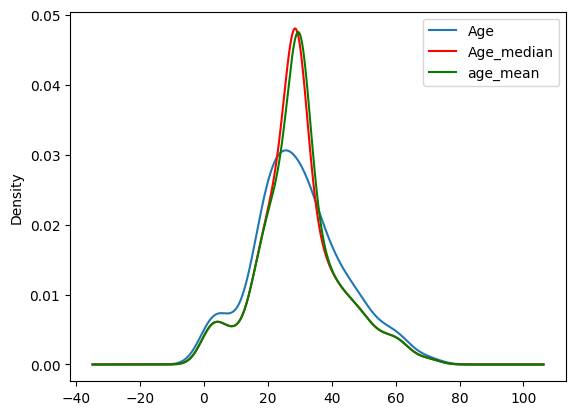

In [29]:
fig=plt.figure()
ax=fig.add_subplot(111)

# orignal variable distribuation
X_train['Age'].plot(kind='kde',ax=ax)

#variable imputer with median
X_train["Age_median"].plot(kind='kde',ax=ax,color='red')

#variable imouter with mean
X_train['age_mean'].plot(kind='kde',ax=ax,color='green')

lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

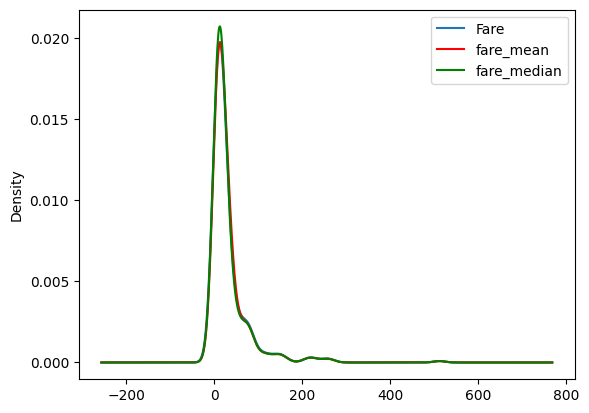

In [30]:
fig=plt.figure()
ax=fig.add_subplot(111)
X_train['Fare'].plot(kind='kde',ax=ax)
X_train['fare_mean'].plot(kind='kde',ax=ax, color='red')
X_train['fare_median'].plot(kind='kde',ax=ax,color='green')

lines,labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc='best')

In [31]:
X_train.cov()

,Age,Fare,Family,Age_median,age_mean,fare_mean,fare_median
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,66.665205,64.858859
Fare,70.719262,2448.197914,17.258917,57.957599,55.603719,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.112563,-5.146106,16.385048,16.476305
Age_median,204.349513,57.957599,-5.112563,161.989566,161.812625,55.023037,53.553455
age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,52.788341,51.358000
fare_mean,66.665205,2448.197914,16.385048,55.023037,52.788341,2324.238526,2324.238526
fare_median,64.858859,2448.197914,16.476305,53.553455,51.358000,2324.238526,2340.091022


<Axes: >

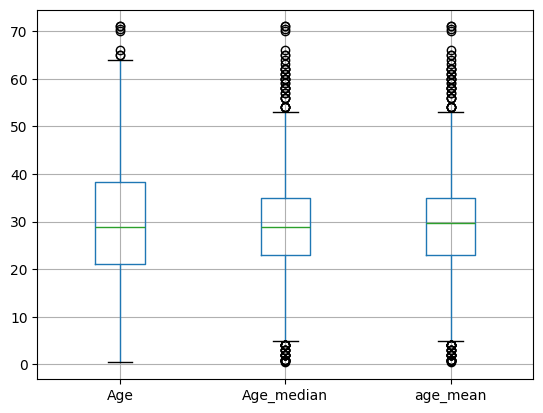

In [33]:
X_train[['Age','Age_median','age_mean']].boxplot()

<Axes: >

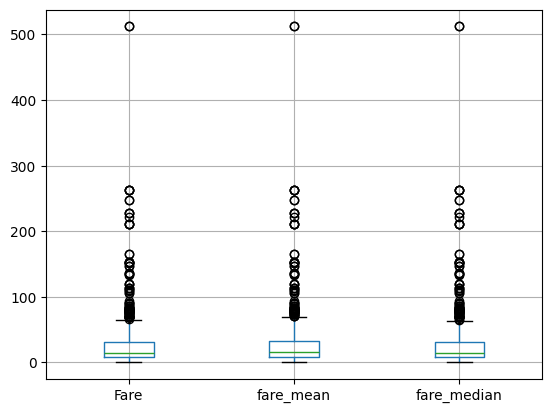

In [35]:
X_train[['Fare','fare_mean','fare_median']].boxplot()

## Using sklearn

In [36]:
X_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)


In [37]:
imputer1=SimpleImputer(strategy='median')
imputer2=SimpleImputer(strategy='mean')

In [38]:
trf=ColumnTransformer([
    ('imputer1',imputer1,['Age']),
    ('imputer2',imputer2,['Fare'])
],remainder='passthrough')

In [39]:
trf.fit(X_train)

c:\Users\Hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [40]:
trf.named_transformers_['imputer1'].statistics_

array([28.75])

In [41]:
trf.named_transformers_['imputer2'].statistics_

array([32.61759689])

In [42]:
X_train=trf.transform(X_train)
X_test=trf.transform(X_test)

In [43]:
X_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 28.75  , 221.7792,   0.    ],
       [ 28.75  ,  25.925 ,   0.    ]])